[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Epoch 1/10 | Loss: 0.6253 | F1: 0.6774 | Acc: 0.7505
Epoch 2/10 | Loss: 0.4620 | F1: 0.6921 | Acc: 0.7669
Epoch 3/10 | Loss: 0.3509 | F1: 0.7111 | Acc: 0.7669
Epoch 4/10 | Loss: 0.2679 | F1: 0.7012 | Acc: 0.7617
Epoch 5/10 | Loss: 0.1981 | F1: 0.7049 | Acc: 0.7603
Early stopping triggered.

Final Validation Result:
F1 Score: 0.7111
Accuracy: 0.7669

Final Evaluation Report:
              precision    recall  f1-score   support

         0.0       0.78      0.84      0.80       874
         1.0       0.75      0.67      0.71       649

    accuracy                           0.77      1523
   macro avg       0.76      0.75      0.76      1523
weighted avg       0.77      0.77      0.76      1523



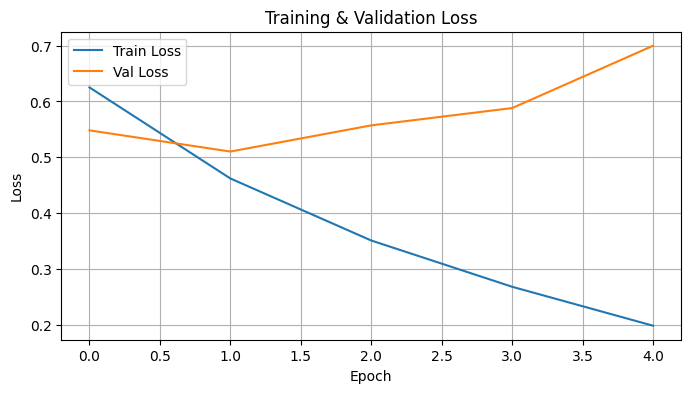

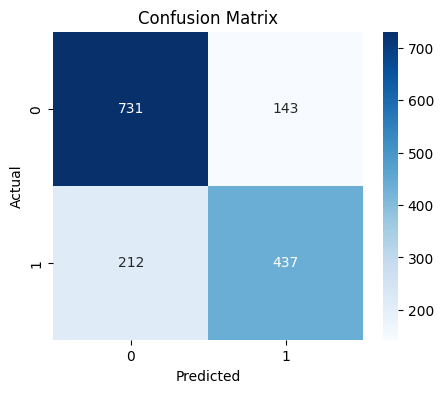

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 安裝與載入套件
!pip install emoji --quiet

import pandas as pd
import re
import string
import nltk
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import emoji
import numpy as np
import random
import copy
from torch.nn.utils.rnn import pack_padded_sequence
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# 固定隨機種子，讓結果可以重現
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# 前處理函數
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", '', text)
    text = re.sub(r"@\w+", '', text)
    text = text.replace('#', ' ')  # 保留 hashtag 的字（#earthquake 是很強的災難訊號），只拿掉 # 符號
    text = remove_emoji(text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

# 載入並處理資料集
df = pd.read_csv('/content/train.csv')
df['tokens'] = df['text'].astype(str).apply(preprocess)

# 所有模型共用同一個切分：test_size=0.2, random_state=42, stratify=target
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

# 詞表只用訓練集建立，避免驗證集的字彙洩漏到模型
all_tokens = [token for tokens in train_df['tokens'] for token in tokens]
vocab_counter = Counter(all_tokens)
vocab = {'<PAD>': 0, '<UNK>': 1}
for idx, (word, _) in enumerate(vocab_counter.most_common(10000), start=2):
    vocab[word] = idx

def tokens_to_ids(tokens, max_len=50):
    ids = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    return ids[:max_len] + [0] * (max_len - len(ids))

train_ids = train_df['tokens'].apply(tokens_to_ids).tolist()
val_ids = val_df['tokens'].apply(tokens_to_ids).tolist()
train_labels = train_df['target'].tolist()
val_labels = val_df['target'].tolist()

# Dataset & Dataloader
class TweetDataset(Dataset):
    def __init__(self, input_ids, labels):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.labels[idx]

train_dataset = TweetDataset(train_ids, train_labels)
val_dataset = TweetDataset(val_ids, val_labels)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# BiLSTM 模型
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, output_dim=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        # 依實際長度打包，最後的 hidden state 才不會被後面補的 <PAD> 影響
        lengths = (x != 0).sum(dim=1).clamp(min=1).cpu()
        packed = pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        hidden = torch.cat((hidden[0], hidden[1]), dim=1)
        return self.fc(self.dropout(hidden)).squeeze(1)

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss < self.best_score - self.min_delta:
            self.best_score = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# 訓練模型 + 評估與視覺化
def train_model(model, train_loader, val_loader, epochs=10, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()
    early_stopping = EarlyStopping(patience=patience)

    train_losses_all, val_losses_all = [], []
    best_f1, best_acc = 0, 0
    best_state = None
    final_preds, final_targets = [], []

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses, preds, targets = [], [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_losses.append(loss.item())
                probs = torch.sigmoid(outputs)
                pred_labels = (probs > 0.5).long()
                preds.extend(pred_labels.cpu().numpy())
                targets.extend(labels.cpu().numpy())

        val_loss = np.mean(val_losses)
        f1 = f1_score(targets, preds)
        acc = np.mean(np.array(preds) == np.array(targets))

        train_losses_all.append(np.mean(train_losses))
        val_losses_all.append(val_loss)

        if f1 > best_f1:
            best_f1 = f1
            best_acc = acc
            final_preds, final_targets = preds.copy(), targets.copy()
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{epochs} | Loss: {np.mean(train_losses):.4f} | F1: {f1:.4f} | Acc: {acc:.4f}")
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    # 還原 F1 最高那一輪的權重：原本測試集是用早停時最後一輪的權重預測，與回報的最佳 F1 不是同一個模型
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final 評估輸出
    print(f"\nFinal Validation Result:")
    print(f"F1 Score: {best_f1:.4f}")
    print(f"Accuracy: {best_acc:.4f}")

    # 最終 classification report
    print("\nFinal Evaluation Report:")
    print(classification_report(final_targets, final_preds, digits=2))

    #  Loss 圖
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses_all, label='Train Loss')
    plt.plot(val_losses_all, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training & Validation Loss')
    plt.grid()
    plt.show()

    #  混淆矩陣
    cm = confusion_matrix(final_targets, final_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# 訓練模型
model = LSTMClassifier(vocab_size=len(vocab))
train_model(model, train_loader, val_loader)

# 預測測試集並儲存 submission
test_df = pd.read_csv('/content/test.csv')
test_df['tokens'] = test_df['text'].astype(str).apply(preprocess)
test_df['input_ids'] = test_df['tokens'].apply(lambda x: tokens_to_ids(x))

test_inputs = torch.tensor(test_df['input_ids'].tolist(), dtype=torch.long)
test_loader = DataLoader(test_inputs, batch_size=32)

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

predictions = []
with torch.no_grad():
    for inputs in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long().cpu().numpy()
        predictions.extend(preds)

submission = pd.DataFrame({
    'id': test_df['id'],
    'target': predictions
})
submission.to_csv('/content/submission.csv', index=False)
files.download('/content/submission.csv')